In [1]:
%load_ext autoreload
%autoreload 2

#### Importing

In [2]:
import json
from functools import partial
import numpy as np
import pandas as pd
import torch
from fancy_einsum import einsum

from transformers import AutoModelForCausalLM
from datasets import load_from_disk


import transformer_lens as tl
from circuitsvis.attention import attention_heads
import transformer_lens.utils as utils
from transformer_lens import ActivationCache, HookedTransformer, HookedTransformerConfig

from geomechinterp.causal.mygpt import SymbolTokenizer, DataCollator
from geomechinterp.tflens.utils import load_gpt2_to_hooked_transformer
from geomechinterp.causal.base_functions import ALL_BINARY_GENERATOR_FUNC_NAMES
from geomechinterp.causal.utils import DisplayChain

In [3]:
from IPython.display import HTML, IFrame
from tqdm import tqdm

import plotly.express as px
import plotly.graph_objects as go
from matplotlib import pyplot as plt
import plotly.io as pio

#### Loading Model

In [34]:
ls ../

2774.94s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
ls: /gpt_: No such file or directory


In [4]:
model_hf = AutoModelForCausalLM.from_pretrained("../gpt_rope_custom/checkpoint-407000/")


hook_config = HookedTransformerConfig(d_vocab=29, n_ctx=128, d_model=128,
                                      d_head=32, n_layers=6, n_heads=4,
                                      rotary_dim=64, act_fn='gelu_new', 
                                      original_architecture='GPT2LMHeadModel')

model = load_gpt2_to_hooked_transformer(model_hf, hook_config)

# model.tokenizer = SymbolTokenizer()

model_hf.to("mps").eval()
model.to("mps").eval()
print('')

Moving model to device:  mps



In [5]:
input_ids = torch.tensor([1, 2, 3, 3, 1, 2, 5, 6, 2, 10, 2, 3, 15, 18, 20, 7]).to("mps")

out1 = model_hf(input_ids)
out2, hooked_act = model.run_with_cache(input_ids)

k = 1
print('WARNING: SMALL DIFFERENCES IN ACTIVATIONS ARE ACCUMULATING, PROBABLY DUE TO DISREPANCIES IN THE LAYER NORM!')
print('---'*10)
for k in range(out2.shape[1]):
    # use cosine similarity after softmax
    print(torch.cosine_similarity(torch.nn.functional.softmax(out1['logits'][k,:], dim=-1), torch.nn.functional.softmax(out2[:,k,:], dim=-1)).item())    


------------------------------
0.9993540048599243
1.0
1.0
0.999977707862854
1.0
1.0
0.9522892832756042
1.0
0.9994153380393982
0.9347359538078308
1.0
1.0
0.9226438403129578
0.9750189185142517
0.9235071539878845
0.9390167593955994


#### Loading Dataset

In [6]:
tokenizer = SymbolTokenizer()
dataset = load_from_disk("../tokenized_train")
test_dataset = load_from_disk("../tokenized_test")

train_collator = DataCollator(dataset, device="mps")  
test_collator = DataCollator(test_dataset, device="mps")  

In [8]:
dataset

Dataset({
    features: ['text', 'generator', 'stochastic', 'sequence_of_features', 'input_ids'],
    num_rows: 407353
})

In [9]:
# select subset of deterministic patterns
deterministic_train_dataset = []
for case in dataset:
    if case['stochastic']:
        continue
    else:
        deterministic_train_dataset.append(case)

deterministic_test_dataset = []
for case in test_dataset:
    if case['stochastic']:
        continue
    else:
        deterministic_test_dataset.append(case)

print(len(deterministic_train_dataset))
print(len(deterministic_test_dataset))

1011
46


In [10]:
deterministic_test_dataset[0]['generator']

{'functions': [{'control_features': ['ab_prev', 'position_parity'],
   'function': 'ab_f',
   'global_control': None,
   'truth_table_values': [1, 0, 0, 1],
   'type': 'DependentFeatureWrapper'},
  {'control_features': ['ab', 'ab_prev', 'position_parity'],
   'function': 'plus_minus_f',
   'global_control': None,
   'truth_table_values': [0, 0, 1, 0, 1, 0, 1, 1],
   'type': 'DependentFeatureWrapper'},
  {'control_features': ['+-', 'ab', 'ab_prev'],
   'function': 'case_f',
   'global_control': None,
   'truth_table_values': [1, 0, 0, 1, 1, 0, 1, 0],
   'type': 'DependentFeatureWrapper'}],
 'type': 'DisplayChain'}

In [11]:
from datasets import Dataset

deterministic_test_dataset = Dataset.from_list(deterministic_test_dataset)
deterministic_train_dataset = Dataset.from_list(deterministic_train_dataset)

# drop all rows with text length < 5
deterministic_train_dataset = deterministic_train_dataset.filter(lambda x: len(x['text']) > 5)
deterministic_test_dataset = deterministic_test_dataset.filter(lambda x: len(x['text']) > 5)

Filter:   0%|          | 0/1011 [00:00<?, ? examples/s]

Filter:   0%|          | 0/46 [00:00<?, ? examples/s]

In [47]:
from geomechinterp.causal.pattern_generator import build_features_dataframe
df_features = build_features_dataframe(deterministic_train_dataset)

In [50]:
list(df_features.columns)

['num_functions',
 'num_edges',
 'num_indep_funcs',
 'presence_+-',
 'presence_><',
 'presence_][',
 'max_control',
 'total_tt_symmetry_complexity',
 'tt_size_4_count',
 'tt_size_4_OR',
 'tt_size_8_count',
 'tt_size_8_tt_sym_0',
 'tt_size_8_tt_sym_1',
 'tt_size_8_tt_sym_2',
 'tt_size_4_XOR',
 'tt_size_2_count',
 'tt_size_2_tt_sym_0',
 'tt_size_2_balanced',
 'tt_size_4_NOT_A_OR_B',
 'tt_size_4_A_OR_NOT_B',
 'tt_size_8_balanced',
 'tt_size_4_XNOR',
 'tt_size_4_NAND',
 'tt_size_4_NOR',
 'tt_size_4_NOT_A_AND_B',
 'tt_size_4_AND',
 'tt_size_4_A_AND_NOT_B',
 'dag_equivalence_class_31',
 'dag_equivalence_class_7',
 'dag_equivalence_class_6',
 'dag_equivalence_class_20',
 'dag_equivalence_class_25',
 'dag_equivalence_class_10',
 'dag_equivalence_class_37',
 'dag_equivalence_class_30',
 'dag_equivalence_class_12',
 'dag_equivalence_class_16',
 'dag_equivalence_class_22',
 'dag_equivalence_class_13',
 'dag_equivalence_class_4',
 'dag_equivalence_class_21',
 'dag_equivalence_class_36',
 'dag_equi

In [54]:
len(df_features), len(deterministic_train_dataset)

(1010, 1010)

In [51]:
deterministic_train_dataset[0]

{'text': '+a +a +b -b +a +a +b -b +a +a +b -b +a +a +b -b +a +a +b -b +a +a +b -b +a +a +b -b +a +a',
 'generator': {'functions': [{'control_features': ['ab_prev',
     'position_parity'],
    'function': 'plus_minus_f',
    'global_control': None,
    'truth_table_values': [0, 1, 1, 1],
    'type': 'DependentFeatureWrapper'},
   {'control_features': ['+-', 'ab_prev', 'position_parity'],
    'function': 'ab_f',
    'global_control': None,
    'truth_table_values': [0, 1, 0, 1, 0, 1, 0, 0],
    'type': 'DependentFeatureWrapper'},
   {'control_features': ['+-', 'ab', 'position_parity'],
    'function': 'case_f',
    'global_control': None,
    'truth_table_values': [0, 1, 0, 0, 1, 0, 1, 0],
    'type': 'DependentFeatureWrapper'}],
  'type': 'DisplayChain'},
 'stochastic': False,
 'sequence_of_features': ['position_parity', 'ab_prev', 'ab', 'case', '+-'],
 'input_ids': [5,
  0,
  4,
  5,
  0,
  4,
  5,
  1,
  4,
  6,
  1,
  4,
  5,
  0,
  4,
  5,
  0,
  4,
  5,
  1,
  4,
  6,
  1,
  4,
  

In [77]:

# print("Loading model...")
# model_hf = AutoModelForCausalLM.from_pretrained("/Users/solar/Code/DL/Mechanistic_Interpretability/GeoMechInterp/gpt_rope_custom/checkpoint-407000")

# tokenizer = SymbolTokenizer()
# dataset = load_from_disk("/Users/solar/Code/DL/Mechanistic_Interpretability/GeoMechInterp/tokenized_train")
# test_dataset = load_from_disk("/Users/solar/Code/DL/Mechanistic_Interpretability/GeoMechInterp/tokenized_test")

# train_collator = DataCollator(dataset, device="mps")  
# test_collator = DataCollator(test_dataset, device="mps")  

from mixed_dag_presentation import collect_batch, PCA, sns

print("Collecting batch...")
rows = collect_batch(model_hf, deterministic_train_dataset, tokenizer=tokenizer, layer=5,)


In [78]:
df_features.

,num_functions,num_edges,num_indep_funcs,presence_+-,presence_><,presence_][,max_control,total_tt_symmetry_complexity,tt_size_4_count,tt_size_4_OR,...,labeled_graph_hash_21,labeled_graph_hash_7,labeled_graph_hash_88,labeled_graph_hash_153,labeled_graph_hash_116,labeled_graph_hash_151,labeled_graph_hash_137,labeled_graph_hash_106,labeled_graph_hash_114,labeled_graph_hash_79
0,3,8,0,1,0,0,3,11,1.0,2.0,...,False,False,False,False,False,False,False,False,False,False
1,3,5,1,1,0,0,3,9,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,3,6,0,1,0,0,3,7,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,3,8,0,1,0,0,3,10,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,3,8,0,1,0,0,3,9,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005,3,8,0,1,0,0,3,9,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1006,2,5,0,1,0,0,3,6,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1007,3,8,0,1,0,0,3,8,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1008,3,7,0,1,0,0,3,9,2.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:



print("PCA...")
X = np.stack([r['activation'] for r in rows])        # N × d_model

# Add annotations from df_features into df, aligned by rows
# Find all columns in df_features that start with 'dag_equivalence_class'
dag_eq_cols = [col for col in df_features.columns if col.startswith('dag_equivalence_class')]

# For each row, find which dag_equivalence_class column is True (or 1)
def get_dag_eq_class(row):
    for col in dag_eq_cols:
        if row[col]:
            return col
    return 'None'

# Build the annotation array
dag_eq_classes = df_features.apply(get_dag_eq_class, axis=1).values

# pca is stacked by positions in each sequence, so you need to repeat dag_eq_classes as well
# Each row in 'rows' corresponds to a prefix position in a sequence, and the sequence index is i // n_prefixes_per_seq
# We'll assume that for each sequence in df_features, there are a variable number of prefix positions in rows
# So, for each row in rows, we need to know which sequence it came from.
# If rows[i] corresponds to sequence j, then dag_eq_classes[j] is the label.

# If 'rows' contains a 'seq_idx' or similar, use that. Otherwise, assume rows are grouped by sequence in order.
# Let's try to infer the mapping:
# We'll try to get the number of rows per sequence by dividing len(rows) by len(df_features)
n_seqs = len(df_features)
n_rows = len(rows)
if n_rows % n_seqs == 0:
    n_per_seq = n_rows // n_seqs
    dag_eq_classes_repeated = np.repeat(dag_eq_classes, n_per_seq)
    if len(dag_eq_classes_repeated) != n_rows:
        print(f"Warning: repeated dag_eq_classes ({len(dag_eq_classes_repeated)}) does not match rows ({n_rows})")
else:
    # Fallback: try to assign by cycling through dag_eq_classes
    print(f"Warning: rows ({n_rows}) not divisible by df_features ({n_seqs}), repeating/cycling labels")
    dag_eq_classes_repeated = np.resize(dag_eq_classes, n_rows)

pca = PCA(n_components=2).fit_transform(X)
df  = pd.DataFrame({
    'PC1': pca[:,0],
    'PC2': pca[:,1],
    'color_by': dag_eq_classes_repeated,
    # 'dag_equivalence_class': dag_eq_classes_repeated
})

print("Plotting...")
sns.scatterplot(data=df, x='PC1', y='PC2', hue='color_by', s=20, linewidth=0)
plt.title("Residual-stream geometry coloured by DAG equivalence class")
plt.axis('equal'); plt.tight_layout()
plt.savefig("residual_stream_geometry_colored_by_dag_topology.png")

In [107]:
import collections
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from geomechinterp.causal.belief_update import chars_to_chain_tokens

# ---------------------------------------------------------------------
# 1.  Build global n-gram count tables (1-gram … 4-gram), **including**
#     the predicted token in each key
# ---------------------------------------------------------------------
def build_ngram_counts(dataset, max_n=4):
    tables = [collections.Counter() for _ in range(max_n)]
    for entry in dataset:
        # turn the string into a list of characters, so we keep blanks:
        char_list = list(entry["text"])
        chain_tok = chars_to_chain_tokens(char_list)
        L = len(chain_tok)

        for t in range(L):
            # for each order n, grab the last n tokens *including* position t
            for n in range(1, max_n + 1):
                if t + 1 - n < 0:
                    continue
                key = tuple(chain_tok[t + 1 - n : t + 1])
                tables[n - 1][key] += 1

    return tables


# ---------------------------------------------------------------------
# 2.  Mixture cross-entropy for prefix length k
# ---------------------------------------------------------------------
def ngram_mixture_cross_entropy(k, dataset, tables, weights=None):
    max_n = len(tables)
    if weights is None:
        weights = np.full(max_n, 1 / max_n)

    # build global vocab of chain-tokens
    vocab = set()
    for entry in dataset:
        char_list = list(entry["text"])
        vocab.update(chars_to_chain_tokens(char_list))

    total_logprob, count = 0.0, 0
    for entry in dataset:
        char_list = list(entry["text"])
        tokens    = chars_to_chain_tokens(char_list)
        L = len(tokens)

        # only evaluate positions with exactly prefix length == k
        for t in range(1, L):
            if t != k:
                continue
            true_tok = tokens[t]

            # mix over n=1..4
            p_mix = 0.0
            for n, tab in enumerate(tables, start=1):
                if t + 1 - n < 0:
                    continue

                # form the n-gram ending at t
                ngram = tuple(tokens[t + 1 - n : t + 1])

                if n == 1:
                    # unigram: denominator is total count of all 1-grams
                    denom = sum(tab.values())
                    num   = tab.get((true_tok,), 0)
                else:
                    # context = the first n-1 tokens of our ngram
                    context = ngram[:-1]
                    # denom = sum of all n-grams sharing that context
                    denom = sum(cnt for gram, cnt in tab.items() if gram[:-1] == context)
                    num   = tab.get(ngram, 0)

                p_n = num / denom if denom > 0 else 0.0
                p_mix += weights[n - 1] * p_n

            # avoid log(0)
            p_mix = max(p_mix, 1e-12)
            total_logprob -= math.log2(p_mix)
            count += 1

    return total_logprob / max(count, 1)


In [120]:
import random
random_indices = random.sample(range(len(dataset)), 20000)
dataset_to_run = [dataset[i] for i in random_indices]

In [126]:
ng_tables = build_ngram_counts(dataset_to_run, max_n=3)
# ---------------------------------------------------------------------
# 3.  Assemble KL-gap vs. n-gram gap dataframe
# ---------------------------------------------------------------------
gap_by_k = collections.defaultdict(list)
for r in rows:
    gap_by_k[r['prefix_len']].append(r['kl_gap'])

data = {'prefix_len': [], 'KL_gap': [], 'ngram_gap': []}
for k in sorted(gap_by_k):
    model_gap = np.mean(gap_by_k[k])
    ngram_ce  = ngram_mixture_cross_entropy(k, dataset_to_run, tables=ng_tables)
    data['prefix_len'].append(k)
    data['KL_gap'].append(model_gap)
    # positive ngram_gap means model is better than n-gram
    data['ngram_gap'].append(ngram_ce - model_gap)

df2 = pd.DataFrame(data)

In [130]:
df2

,prefix_len,KL_gap,ngram_gap
0,0,18.977450,-18.977450
1,1,16.960336,-13.338115
2,2,17.920636,-15.095278
3,3,18.247171,-15.423529
4,4,18.438407,-15.612855
5,5,19.085575,-16.257494
6,6,18.822516,-15.994122
7,7,18.864376,-16.032775
8,8,18.690011,-15.861540
9,9,18.638042,-15.812082


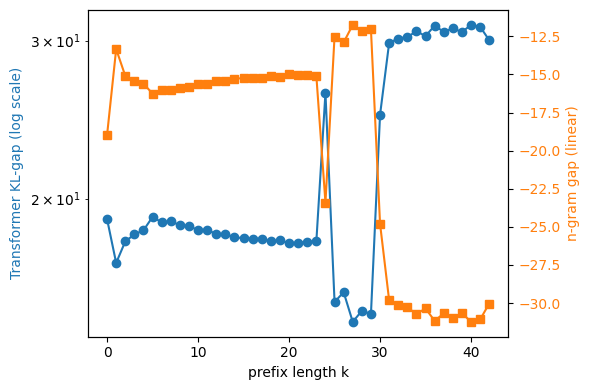

In [127]:
fig, ax1 = plt.subplots(figsize=(6,4))
# Transformer KL-gap on log-y
ax1.plot(df2['prefix_len'], df2['KL_gap'], marker='o', color='C0', label="Transformer KL-gap")
ax1.set_yscale('log')
ax1.set_xlabel("prefix length k")
ax1.set_ylabel("Transformer KL-gap (log scale)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# n-gram gap on a second, linear y-axis
ax2 = ax1.twinx()
ax2.plot(df2['prefix_len'], df2['ngram_gap'], marker='s', color='C1', label="n-gram mixture gap")
ax2.set_ylabel("n-gram gap (linear)", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

fig.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(df2['prefix_len'], df2['KL_gap'],   marker='o', label="Transformer KL-gap")
plt.plot(df2['prefix_len'], df2['ngram_gap'], marker='s', label="n-gram mixture gap")
plt.yscale('log')
plt.xlabel("prefix length k")
plt.ylabel("extra bits vs oracle")
plt.legend()
plt.tight_layout()
plt.show()

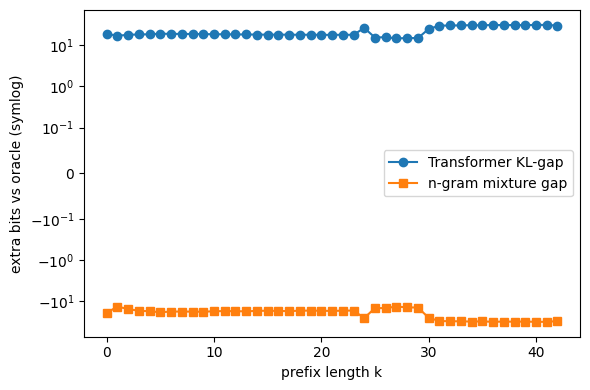

In [103]:
plt.figure(figsize=(6,4))
plt.plot(df2['prefix_len'], df2['KL_gap'],     marker='o', label="Transformer KL-gap")
plt.plot(df2['prefix_len'], df2['ngram_gap'], marker='s', label="n-gram mixture gap")
plt.yscale('symlog', linthresh=0.1)    # linear region for |y|<0.1, log beyond
plt.xlabel("prefix length k")
plt.ylabel("extra bits vs oracle (symlog)")
plt.legend()
plt.tight_layout()
plt.show()

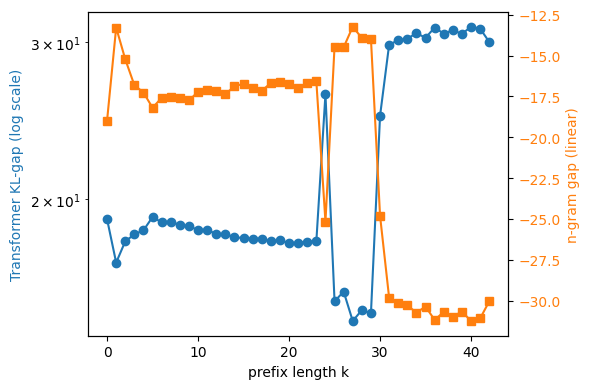

In [104]:
fig, ax1 = plt.subplots(figsize=(6,4))

# Transformer KL-gap on log-y
ax1.plot(df2['prefix_len'], df2['KL_gap'], marker='o', color='C0', label="Transformer KL-gap")
ax1.set_yscale('log')
ax1.set_xlabel("prefix length k")
ax1.set_ylabel("Transformer KL-gap (log scale)", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# n-gram gap on a second, linear y-axis
ax2 = ax1.twinx()
ax2.plot(df2['prefix_len'], df2['ngram_gap'], marker='s', color='C1', label="n-gram mixture gap")
ax2.set_ylabel("n-gram gap (linear)", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

fig.tight_layout()
plt.show()

In [13]:
idx = 11
test_case = deterministic_test_dataset[idx]
out = model(torch.tensor(test_case['input_ids']).to("mps"))
decoded_str = tokenizer.decode(out.argmax(dim=-1).tolist())[0]

print(DisplayChain.from_json(test_case['generator'], base_functions=ALL_BINARY_GENERATOR_FUNC_NAMES))
print(test_case['text'][6:])
print(decoded_str[5:])

Chain of functions:
DependentFeature(function=ab_f, controls=[ab_prev, position_parity], truth_table=[0, 1, 1, 0])
DependentFeature(function=case_f, controls=[ab, ab_prev, position_parity], truth_table=[0, 1, 1, 0, 1, 0, 1, 0])
DependentFeature(function=plus_minus_f, controls=[ab, ab_prev, case], truth_table=[1, 1, 1, 1, 1, 1, 1, 0])
B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+
a+ a- a+ a+ B+ b+ B+ a+ B+ b+ B+ b+ B+ b+ a+ b+ B+ b+ a+ a+ B+ b+ b


In [14]:
from geomechinterp.causal.belief_update import compare_batch, oracle_next_probs, chars_to_chain_tokens, CharStreamer, oracle_next_probs_char, oracle_entropy
from geomechinterp.causal.pattern_generator import generate_pattern


In [15]:
SEQLEN = 20
idx = 11
chain_str = deterministic_test_dataset[idx]
print(chain_str['text'])
chain = DisplayChain.from_json(chain_str['generator'], base_functions=ALL_BINARY_GENERATOR_FUNC_NAMES)
print('\n')


last_1 = "a+"
last_2 = "b+"
print(generate_pattern(chain, start_string=f'C+ a- b- a- b+ {last_1}', pattern_length=25))
print(generate_pattern(chain, start_string=f'C+ a- b- a- b+ {last_2}', pattern_length=25))
# realized_function("", s_prev=prev_s, position=(i + position_offset))

chain("", s_prev=last_1, position=0)

a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+


C+ a- b- a- b+ a+ : B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+
C+ a- b- a- b+ b+ : a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+


'B+'

In [16]:
cs = CharStreamer(chain)

# Case 1: we have nothing yet
print(cs.next_char())   # 'b'
print(cs.next_char('b'))# '+'
print(cs.next_char('+'))# 'a'

# Case 2: continue after we already printed "b+"
cs = CharStreamer(chain)
cs.next_char()          # 'b'
cs.next_char('b')       # '+'
# now want to resume later:
print(cs.next_char('+'))  # 'a'

a
+
a
a


In [17]:
print(generate_pattern(chain, start_string=f'a', pattern_length=25))


a : a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+ B+ b+ a+ a+


In [67]:
chain("", s_prev="", position=3)

'b+'

In [72]:
chain("", s_prev="-", position=3)

'b+'

In [75]:
prefix_str = "a+ a+ B+ b+"
prefix = prefix_str.split()  
probs  = oracle_next_probs(chain, prefix, seq_len=SEQLEN)
print(probs)

{'a+': 1.0}


In [76]:
test_prefixes = ['a+ a+ B+ b+', 'a+ a+ B+ b+ a+ a+', 'a+ a+ B+ b+ a+ a+ a+ a+', "b- B+ b+", "ccc", "xxx"]
for prefix in test_prefixes:
    prefix = prefix.split()
    print(oracle_next_probs(chain, prefix, seq_len=SEQLEN))


{'a+': 1.0}
{'B+': 1.0}
{'B+': 1.0}
{'b+': 1.0}
{'b+': 1.0}
{'b+': 1.0}


In [61]:
tok2id = tokenizer.token_to_id
id2tok = tokenizer.id_to_token


In [77]:
input_tensor = torch.tensor(test_case['input_ids']).unsqueeze(0).to("mps")
input_tensor = input_tensor[:, :-12]

prefix_ids  = input_tensor[0].tolist()
char_list   = [id2tok[i] for i in prefix_ids]         # keep blanks!
prefix_tok  = chars_to_chain_tokens(char_list)        # coalesced tokens

seq_len_needed = len(prefix_tok) + 1
probs = oracle_next_probs(chain, prefix_tok, seq_len=seq_len_needed)

In [94]:
compare_batch(model, batch_tokens=input_tensor,  char_streamer=cs, tok2id=tok2id, id2tok=id2tok)

{'b': 1}


(0.0, 24.124927520751953)

#### Visualize MyGPT Activations in Reduced Dimensions

##### Deterministic Patterns Only (0.1% of the dataset)

In [95]:
# blocks.1.attn.hook_z
# blocks.2.hook_mlp_out
# blocks.2.hook_resid_post
# list(hooked_act.keys())

In [44]:
from geomechinterp.ds.emb_pipe import ActivationStatsPipeline   

selected_hooks = [f"blocks.{i}.hook_resid_post" for i in range(1, 6)]

emb_pipe = ActivationStatsPipeline(
    dataset=deterministic_train_dataset,
    activations_dir="tensors",
    activations_file_substring="train_deterministic",
    selected_hooks=selected_hooks,
)

emb_pipe.load_activations()

2025-05-11 10:15:03.997 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-11 10:15:03.998 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-11 10:15:04.097 
  command:

    streamlit run /Users/solar/miniconda3/envs/pytorch/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-05-11 10:15:04.097 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-11 10:15:04.097 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-11 10:15:04.098 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-11 10:15:04.098 No runtime found, using MemoryCacheStorageManager
INFO:root:U

In [13]:
# target_layer = 'blocks.5.hook_resid_post'
# emb_pipe.cluster(activations_str=target_layer, agg_func=0, max_clusters=3, use_isomap=True)
# emb_pipe.plot_pca()

In [ ]:
emb_pipe.streamlit_viz()

In [46]:
results = emb_pipe.run_all()

In [52]:
emb_pipe.calc_activations_svd(cursor='blocks.2.hook_resid_post_4')

{'matrix_rank': 128,
 'spectral_ratio': 0.1749749,
 'frobenius_ratio': 0.6604135,
 'gini': 0.8232334033797917,
 'explained_variance_0.95': 10}

In [38]:
results

{'blocks.1.hook_resid_post_mean': {'clusters': array([0, 0, 1, ..., 0, 1, 1], dtype=int32),
  'matrix_rank': 128,
  'anova':                           Feature   F-statistic        p-value  \
  0                   num_functions  61805.554154   0.000000e+00   
  3                     presence_+-   1194.271040  1.631541e-266   
  4                     presence_><   1194.271040  1.631541e-266   
  5                     presence_][   1194.271040  1.631541e-266   
  6                     max_control    955.869104  1.993351e-233   
  16             tt_size_8_tt_sym_0    681.170826  7.948713e-188   
  18             tt_size_8_tt_sym_2    681.170826  7.948713e-188   
  17             tt_size_8_tt_sym_1    681.170826  7.948713e-188   
  15                tt_size_8_count    681.170826  7.948713e-188   
  1                       num_edges    645.133509  4.522302e-181   
  7    total_tt_symmetry_complexity    311.915746  3.778871e-106   
  9            pattern_entropy_char    241.234788   2.534599e

#### Try predicting Analytical Features from Activations

In [232]:
from geomechinterp.ds.cluster import calculate_feature_importance, single_position, mean_across_positions, agg_across_positions

# Aggregate activations and calculate feature importance for clustering
positions = [0, 1, 2, 3, 4]  # Available positions
activations_np = accumulated_activations['blocks.5.hook_resid_post'].detach().cpu().numpy()
binarized_features = cat_data.to_numpy()
feature_names = cat_data.columns

# IMPORTANT - FEATURES HERE ARE CHANNELS IN THE LLM ACTIVATIONS, NOT THE "ANALYTICAL" FEATURES OF THE PATTERNS
# SO IT IS ESSENTIALLY A VARIATION ON THE LINEAR PROBE TEST

position_importances = {}
for pos in positions:
    X = single_position(activations_np, pos)
    y = binarized_features[:, 0]  # Example target: first binary feature
    importance_df, _ = calculate_feature_importance(X, y)
    # rename features from idx to column names
    importance_df.rename(columns={0: 'Feature'}, inplace=True)
    position_importances[pos] = importance_df

# b) Mean across positions
X_mean = mean_across_positions(activations_np)
y_mean = binarized_features[:, 0]  # Example target
mean_importance_df, _ = calculate_feature_importance(X_mean, y_mean)


# c) Aggregate across positions
X_agg = agg_across_positions(activations_np)
y_agg = binarized_features[:, 0]  # Example target
agg_importance_df, _ = calculate_feature_importance(X_agg, y_agg)

In [233]:
print("Feature Importance for Single Positions:")
for pos, importance in position_importances.items():
    print(f"Position {pos}:")
    print(importance.sort_values(by='RandomForestImportance', ascending=False).head(3))

print("\nFeature Importance for Mean Across Positions:")
print(mean_importance_df.sort_values(by='RandomForestImportance', ascending=False).head(5))

print("\nFeature Importance for Aggregate Across Positions:")
print(agg_importance_df.sort_values(by='RandomForestImportance', ascending=False).head(10))

Feature Importance for Single Positions:
Position 0:
    Feature  RandomForestImportance  PermutationImportance
58       58                0.089877                    0.0
83       83                0.089353                    0.0
11       11                0.089277                    0.0
Position 1:
    Feature  RandomForestImportance  PermutationImportance
85       85                0.050026               0.000792
7         7                0.049765               0.000000
90       90                0.049748               0.000000
Position 2:
    Feature  RandomForestImportance  PermutationImportance
11       11                0.069365                    0.0
83       83                0.069357                    0.0
35       35                0.069061                    0.0
Position 3:
    Feature  RandomForestImportance  PermutationImportance
39       39                0.130574                    0.0
10       10                0.092375                    0.0
73       73               

### Example running on pattern

In [24]:
from geomechinterp.utils import run_model_on_pattern, run_model_on_pattern_and_plot

In [28]:
pattern = 'a a a a a a a a a a a a a a a a a a a a a a a a a'
loss = run_model_on_pattern(model, pattern, tokenizer=tokenizer)
print(loss)

15.801130294799805


In [21]:
device = 'mps'

In [18]:
from geomechinterp.causal.mygpt import SymbolTokenizer


In [19]:
from geomechinterp.causal.mygpt import SymbolTokenizer

tokenizer.init_kwargs = getattr(tokenizer, "init_kwargs", {})
tokenizer.init_kwargs["name_or_path"] = "symbol_tokenizer"
tokenizer.init_kwargs.setdefault("add_bos_token", True)
tokenizer = SymbolTokenizer()
tokenizer.init_kwargs = getattr(tokenizer, "init_kwargs", {})
tokenizer.init_kwargs["name_or_path"] = "symbol_tokenizer"
tokenizer.init_kwargs.setdefault("add_bos_token", True)

model.set_tokenizer(tokenizer)


In [32]:
pattern = 'b b b b b b b b b b b b b b b b b b b b b b b b b'

token_ids = torch.tensor(tokenizer(pattern)["input_ids"]).to(device).unsqueeze(0)

model.run_with_cache(token_ids)
# _ = run_model_on_pattern_and_plot(model, pattern, tokenizer=tokenizer)

(tensor([[[-4.7891e+00, -3.2713e+00, -5.3096e+00,  ..., -1.7878e+01,
           -1.7892e+01, -1.7873e+01],
          [ 1.3352e+00,  5.6682e+00, -3.9639e-02,  ..., -2.3163e+01,
           -2.3163e+01, -2.3124e+01],
          [ 7.4771e-01,  1.6187e+00,  3.6040e-01,  ...,  1.1092e-02,
            6.5444e-03,  1.4117e-02],
          ...,
          [ 4.4580e-01,  9.2116e-01, -2.8926e-01,  ..., -1.4484e-01,
           -1.4797e-01, -1.4961e-01],
          [-1.1016e+00,  8.3196e+00, -2.2569e+00,  ..., -1.8227e+01,
           -1.8224e+01, -1.8205e+01],
          [ 4.2451e-01,  1.0750e+00, -1.1969e-01,  ...,  3.0206e-01,
            2.9423e-01,  2.9434e-01]]], device='mps:0', grad_fn=<ViewBackward0>),
 ActivationCache with keys ['hook_embed', 'hook_pos_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.attn.hook_q', 'blocks.0.attn.hook_k', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern', 'blocks.0.attn.ho

In [33]:
pattern = 'a b a b a b a b a b a b a b a b a b a b a b a b a b'
_ = run_model_on_pattern_and_plot(model, pattern, annotate_tokens=True, tokenizer=tokenizer)

TypeError: iteration over a 0-d tensor

In [ ]:
ALL_DETERMINISTIC_PATTERNS_LIST = list(ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS2.keys())

losses = []
for pattern in ALL_DETERMINISTIC_PATTERNS_LIST:
    loss = run_model_on_pattern(model, pattern[2:], exclude_first_k=5)
    losses.append(loss)

df = pd.DataFrame({'pattern': [p[:29] for p in ALL_DETERMINISTIC_PATTERNS_LIST], 'loss': losses})